# Exploratory Evaluation Notebook

Use this notebook for slicing, filtering, and investigating incomplete or surprising results.

In [1]:
from pathlib import Path
import sys

SEARCH_ROOT = Path.cwd().resolve()
if (SEARCH_ROOT / "evaluation" / "load_results.py").exists():
    sys.path.insert(0, str(SEARCH_ROOT))
    sys.path.insert(0, str(SEARCH_ROOT / "src"))
elif (SEARCH_ROOT / "load_results.py").exists():
    sys.path.insert(0, str(SEARCH_ROOT.parent))
    sys.path.insert(0, str(SEARCH_ROOT.parent / "src"))
else:
    raise RuntimeError("Could not locate the evaluation helpers from the current working directory")

import matplotlib.pyplot as plt
import pandas as pd

from evaluation.load_results import load_results
from evaluation.coverage import compute_coverage, expected_non_oracle_grid, missing_oracle_gap_summary
from evaluation.aggregate import summarize_results
from evaluation.plots import plot_metric_by_dynamicity, plot_tradeoff_scatter
from dvrptw_bench.common.typing import Route, Solution
from dvrptw_bench.data.solomon_parser import parse_solomon
from dvrptw_bench.viz.route_plot import plot_routes_with_labels


In [2]:
df = load_results(include_partial=True)
coverage = compute_coverage(df)
coverage

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/evaluation/load_results.py:164: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[column] = df[column].fillna(False).astype(bool)


,modality_group,model_name,evaluation_size,observed_runs,expected_runs,missing_runs,coverage_ratio,instance_count,seed_count,dod_count,cutoff_count,oracle_gap_coverage_ratio,feasible_rate
0,ai,general_50,50,1505,2688,1183,0.559896,56,3,3,3,1.0,0.091694
1,ai,general_50,75,1512,2688,1176,0.562500,56,3,3,3,0.0,0.031746
2,ai,routefinder_solomon_generated_50,50,1505,2688,1183,0.559896,56,3,3,3,1.0,0.097010
3,ai,routefinder_solomon_generated_50,75,1512,2688,1176,0.562500,56,3,3,3,0.0,0.038360
4,ai,routefinder_solomon_generated_75,50,1505,2688,1183,0.559896,56,3,3,3,1.0,0.134884
5,ai,routefinder_solomon_generated_75,75,1512,2688,1176,0.562500,56,3,3,3,0.0,0.050926
6,ai,routefinder_with_lateness_50,50,1506,2688,1182,0.560268,56,3,3,3,1.0,0.110226
7,ai,routefinder_with_lateness_50,75,1512,2688,1176,0.562500,56,3,3,3,0.0,0.025132
8,ai,routefinder_with_lateness_75,50,1506,2688,1182,0.560268,56,3,3,3,1.0,0.100266
9,ai,routefinder_with_lateness_75,75,1512,2688,1176,0.562500,56,3,3,3,0.0,0.021164


In [3]:
AVAILABLE_MODELS = sorted(df["model_name"].dropna().unique())
AVAILABLE_SIZES = sorted(df["evaluation_size"].dropna().unique())
AVAILABLE_DOD = sorted(df["degree_of_dynamicity"].dropna().unique())
AVAILABLE_CUTOFF = sorted(df["cutoff_time"].dropna().unique())

MODEL_FILTER = AVAILABLE_MODELS
SIZE_FILTER = AVAILABLE_SIZES
DOD_FILTER = AVAILABLE_DOD
CUTOFF_FILTER = AVAILABLE_CUTOFF

filtered = df[
    df["model_name"].isin(MODEL_FILTER)
    & df["evaluation_size"].isin(SIZE_FILTER)
    & df["degree_of_dynamicity"].isin(DOD_FILTER)
    & df["cutoff_time"].isin(CUTOFF_FILTER)
].copy()
filtered.head()


,modality_group,model_name,model_display_name,model_variant,instance_id,instance_family,instance_type,instance_group,evaluation_size,seed,...,total_cost,total_distance,source_file,source_dir,modality_folder,instance_stem,has_oracle_gap,is_complete_run,oracle_subset,coverage_note
0,ai,general_50,RouteFinder General 50,general,C101.txt,C,1,C1,50,851657.0,...,1134.0,634.0,/Users/giuseppe/Documents/personal/fyp-vrp/dvr...,ai,ai,C101,True,True,True,
1,ai,general_50,RouteFinder General 50,general,C101.txt,C,1,C1,50,9547451.0,...,1294.0,694.0,/Users/giuseppe/Documents/personal/fyp-vrp/dvr...,ai,ai,C101,True,True,True,
2,ai,general_50,RouteFinder General 50,general,C101.txt,C,1,C1,50,851657.0,...,1318.0,818.0,/Users/giuseppe/Documents/personal/fyp-vrp/dvr...,ai,ai,C101,True,True,True,
3,ai,general_50,RouteFinder General 50,general,C101.txt,C,1,C1,50,9547451.0,...,1585.0,985.0,/Users/giuseppe/Documents/personal/fyp-vrp/dvr...,ai,ai,C101,True,True,True,
4,ai,general_50,RouteFinder General 50,general,C101.txt,C,1,C1,50,851657.0,...,1662.0,1162.0,/Users/giuseppe/Documents/personal/fyp-vrp/dvr...,ai,ai,C101,True,True,True,


In [4]:
summarize_results(filtered, ["modality_group", "model_display_name", "evaluation_size"])

,modality_group,model_display_name,evaluation_size,runs,feasible_rate,total_distance_mean,total_distance_median,num_vehicles_mean,num_vehicles_median,average_lateness_mean,...,rejection_rate_mean,rejection_rate_median,service_level_mean,service_level_median,computational_time_mean,computational_time_median,total_cost_mean,total_cost_median,oracle_gap_mean,oracle_gap_median
0,ai,RouteFinder General 50,50,1505,0.091694,1854.836545,1836.0,7.603987,7.0,26.232626,...,0.000080,0.0,0.648568,0.760000,0.000000,0.000000,2615.235216,2621.0,170.255620,124.528302
1,ai,RouteFinder General 50,75,1512,0.031746,3073.698413,2929.0,11.441799,11.0,38.600960,...,0.000220,0.0,0.590722,0.653333,0.000000,0.000000,4217.878307,4061.5,NaN,NaN
2,ai,RouteFinder Late 50,50,1506,0.110226,1769.245684,1757.0,7.219124,6.0,24.555984,...,0.000120,0.0,0.663855,0.780000,0.000000,0.000000,2491.158035,2504.5,149.336775,131.976011
3,ai,RouteFinder Late 50,75,1512,0.025132,2847.612434,2821.0,10.433862,9.0,39.589858,...,0.000141,0.0,0.582635,0.640000,0.000000,0.000000,3890.998677,3918.5,NaN,NaN
4,ai,RouteFinder Late 75,50,1506,0.100266,1806.073705,1807.0,7.735724,6.0,24.927579,...,0.000080,0.0,0.665061,0.760000,0.000000,0.000000,2579.646082,2558.5,149.757442,130.413143
5,ai,RouteFinder Late 75,75,1512,0.021164,2848.220238,2779.5,11.154101,8.0,38.975281,...,0.000767,0.0,0.587062,0.640000,0.000000,0.000000,3963.630291,3870.0,NaN,NaN
6,ai,RouteFinder Solomon 50,50,1505,0.097010,2083.957475,1978.0,8.962791,8.0,18.489515,...,0.000106,0.0,0.725835,0.820000,0.000000,0.000000,2980.236545,2843.0,192.303561,175.795190
7,ai,RouteFinder Solomon 50,75,1512,0.038360,3459.781085,3331.5,13.193122,12.0,25.685316,...,0.007769,0.0,0.689267,0.773333,0.000000,0.000000,4779.093254,4686.5,NaN,NaN
8,ai,RouteFinder Solomon 75,50,1505,0.134884,2590.649834,2376.0,10.328904,10.0,14.702664,...,0.000013,0.0,0.740867,0.860000,0.000000,0.000000,3623.540199,3461.0,282.681493,234.727273
9,ai,RouteFinder Solomon 75,75,1512,0.050926,3736.632937,3504.0,13.203042,13.0,21.292577,...,0.000018,0.0,0.698749,0.813333,0.000000,0.000000,5056.937169,4903.5,NaN,NaN


In [5]:
missing_oracle_gap_summary(filtered)

,model_name,evaluation_size,runs,missing_oracle_gap,available_oracle_gap,availability_ratio
0,general_50,50,1729,224,1505,0.870445
1,general_50,75,1736,1736,0,0.000000
2,ortools,50,1568,1568,0,0.000000
3,ortools,75,1568,1568,0,0.000000
4,routefinder_solomon_generated_50,50,1729,224,1505,0.870445
5,routefinder_solomon_generated_50,75,1736,1736,0,0.000000
6,routefinder_solomon_generated_75,50,1729,224,1505,0.870445
7,routefinder_solomon_generated_75,75,1736,1736,0,0.000000
8,routefinder_with_lateness_50,50,1730,224,1506,0.870520
9,routefinder_with_lateness_50,75,1736,1736,0,0.000000


In [6]:
expected_non_oracle_grid(filtered, evaluation_size=50).head()

,instance_id,seed,degree_of_dynamicity,cutoff_time
0,C101.txt,851657.0,0.0,0.2
1,C101.txt,851657.0,0.0,0.5
2,C101.txt,851657.0,0.0,0.8
3,C101.txt,851657.0,0.0,1.0
4,C101.txt,851657.0,0.3,0.2


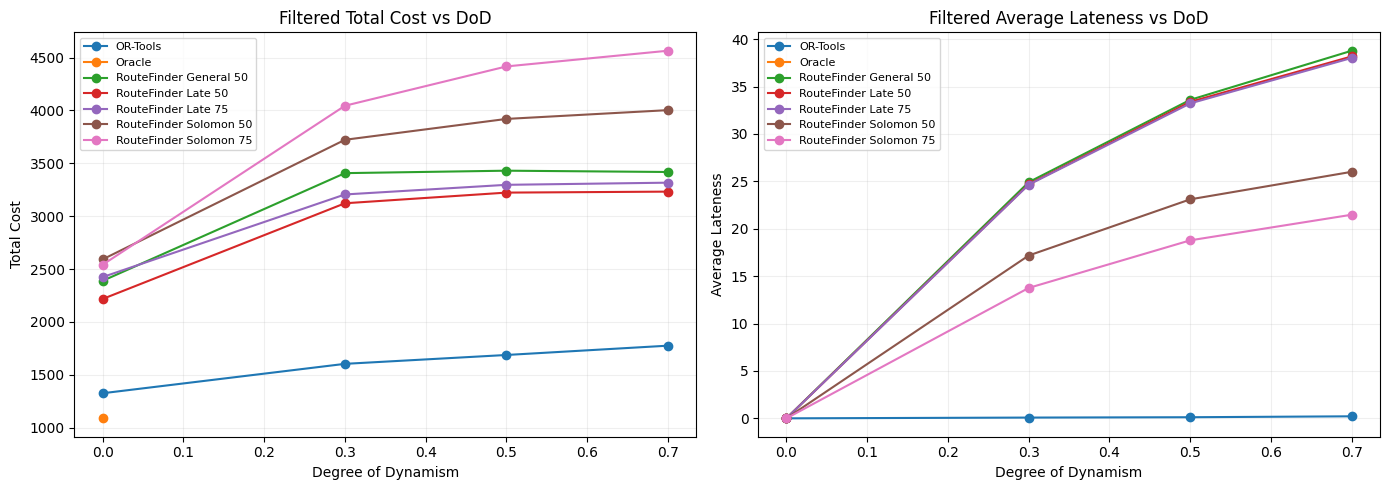

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_metric_by_dynamicity(filtered, metric="total_cost", ax=axes[0])
axes[0].set_title("Filtered Total Cost vs DoD")
plot_metric_by_dynamicity(filtered, metric="average_lateness", ax=axes[1])
axes[1].set_title("Filtered Average Lateness vs DoD")
fig.tight_layout()


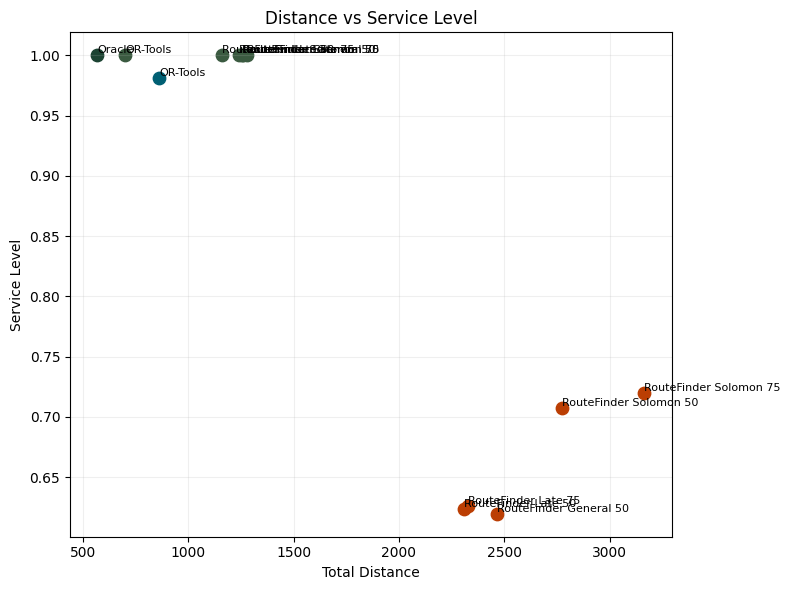

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_tradeoff_scatter(filtered, x="total_distance", y="service_level", ax=ax)
ax.set_title("Distance vs Service Level")
fig.tight_layout()


## Random Solution Samples

Plot one randomly sampled saved solution together with its summary metrics and route list.

model: RouteFinder General 50 (ai)
instance: C207.txt | size=75 | seed=9547451.0
DoD=0.7 | cutoff=0.8
cost=4100.0 | distance=3500.0 | vehicles=6
service_level=0.9333333333333333 | lateness=2.1866666666666665 | rejected=0
routes:
  v0: [20, 30, 24, 35, 38, 33, 37, 31, 23, 19, 16, 25, 47, 43, 10, 8, 42, 48]
  v1: [63, 22, 27, 75, 32, 68, 39, 26, 18, 34, 36, 28, 40, 52, 46, 13, 15, 41]
  v2: [74, 61, 67, 29, 64, 6, 65, 7, 3, 4, 56, 59, 57, 44, 71, 70, 73]
  v3: [5, 72, 1, 66, 69, 55, 54, 53, 58, 60, 45, 9, 21]
  v4: [62, 2, 49, 51, 50, 17, 11]
  v5: [14, 12]


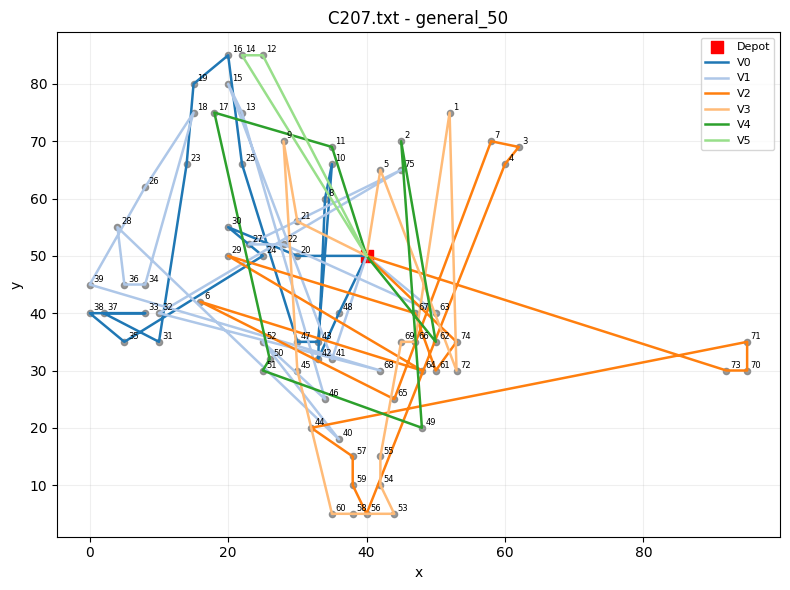

In [9]:
if filtered.empty:
    print("No rows available for plotting under the current filters.")
else:
    row = filtered.sample(1, random_state=None).iloc[0]
    dataset_root = SEARCH_ROOT.parent / "dataset"
    instance_path = dataset_root / row["instance_id"]
    if not instance_path.exists():
        print(dataset_root)
        matches = list(dataset_root.rglob(row["instance_id"]))
        if not matches:
            raise FileNotFoundError(f"Could not locate {row['instance_id']} under {dataset_root}")
        instance_path = matches[0]

    instance = parse_solomon(instance_path, max_customers=int(row["evaluation_size"]))
    solution = Solution(
        strategy=str(row["model_name"]),
        routes=[Route(**route) for route in row["routes"]],
        total_distance=float(row["total_distance"]),
        feasible=bool(row["feasible"]),
        solve_time_s=float(row["computational_time"]),
    )

    print(f"model: {row['model_display_name']} ({row['modality_group']})")
    print(f"instance: {row['instance_id']} | size={int(row['evaluation_size'])} | seed={row['seed']}")
    print(f"DoD={row['degree_of_dynamicity']} | cutoff={row['cutoff_time']}")
    print(f"cost={row['total_cost']} | distance={row['total_distance']} | vehicles={row['num_vehicles']}")
    print(f"service_level={row['service_level']} | lateness={row['average_lateness']} | rejected={row['customers_rejected']}")
    print("routes:")
    for route in row['routes']:
        print(f"  v{route['vehicle_id']}: {route['node_ids']}")

    plot_routes_with_labels(instance, solution)
    plt.show()


,model_display_name,evaluation_size,decode_type,num_samples,num_augment,select_best,runs,total_cost_mean,total_distance_mean,service_level_mean,average_lateness_mean,runtime_mean
0,RouteFinder General 50,50,greedy,1.0,8.0,True,56,1767.553571,919.339286,1.0,0.0,0.082647
1,RouteFinder General 50,50,sampling,1.0,8.0,True,56,2283.214286,1235.000000,1.0,0.0,0.019979
2,RouteFinder General 50,50,sampling,1024.0,8.0,True,56,1819.089286,979.803571,1.0,0.0,0.185979
3,RouteFinder General 50,75,greedy,1.0,8.0,True,56,2617.750000,1383.821429,1.0,0.0,0.212020
4,RouteFinder General 50,75,sampling,1.0,8.0,True,56,3519.928571,1891.357143,1.0,0.0,0.029328
5,RouteFinder General 50,75,sampling,1024.0,8.0,True,56,2718.142857,1511.000000,1.0,0.0,0.328568
6,RouteFinder Late 50,50,greedy,1.0,8.0,True,56,1592.535714,837.178571,1.0,0.0,0.078910
7,RouteFinder Late 50,50,sampling,1.0,8.0,True,56,2165.339286,1122.482143,1.0,0.0,0.020277
8,RouteFinder Late 50,50,sampling,1024.0,8.0,True,56,1700.732143,890.017857,1.0,0.0,0.177142
9,RouteFinder Late 50,75,greedy,1.0,8.0,True,56,2404.750000,1277.964286,1.0,0.0,0.203544


,model_display_name,decode_type,total_cost,service_level,computational_time
0,RouteFinder General 50,greedy,2192.651786,1.0,0.147334
1,RouteFinder General 50,sampling,2585.093750,1.0,0.140963
2,RouteFinder Late 50,greedy,1998.642857,1.0,0.141227
3,RouteFinder Late 50,sampling,2435.977679,1.0,0.134893
4,RouteFinder Late 75,greedy,2136.678571,1.0,0.142789
5,RouteFinder Late 75,sampling,2711.580357,1.0,0.137282
6,RouteFinder Solomon 50,greedy,2396.955357,1.0,0.147076
7,RouteFinder Solomon 50,sampling,2786.428571,1.0,0.142146
8,RouteFinder Solomon 75,greedy,2284.517857,1.0,0.142304
9,RouteFinder Solomon 75,sampling,2797.607143,1.0,0.143584


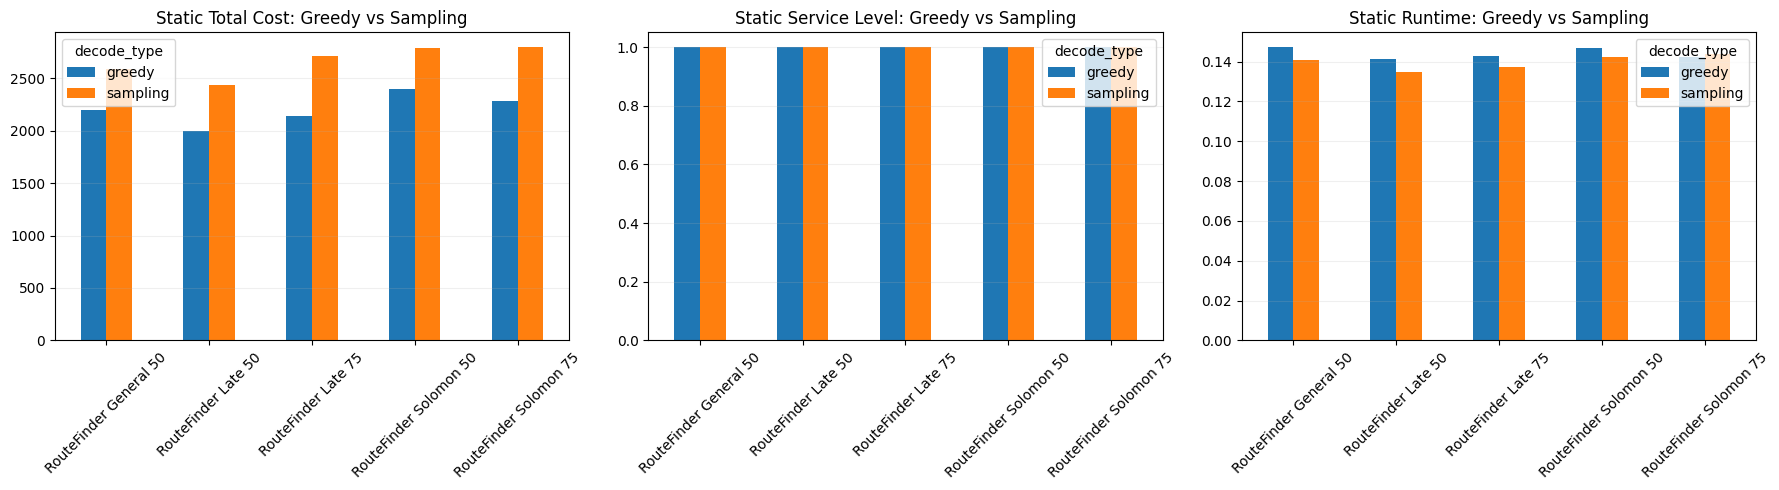

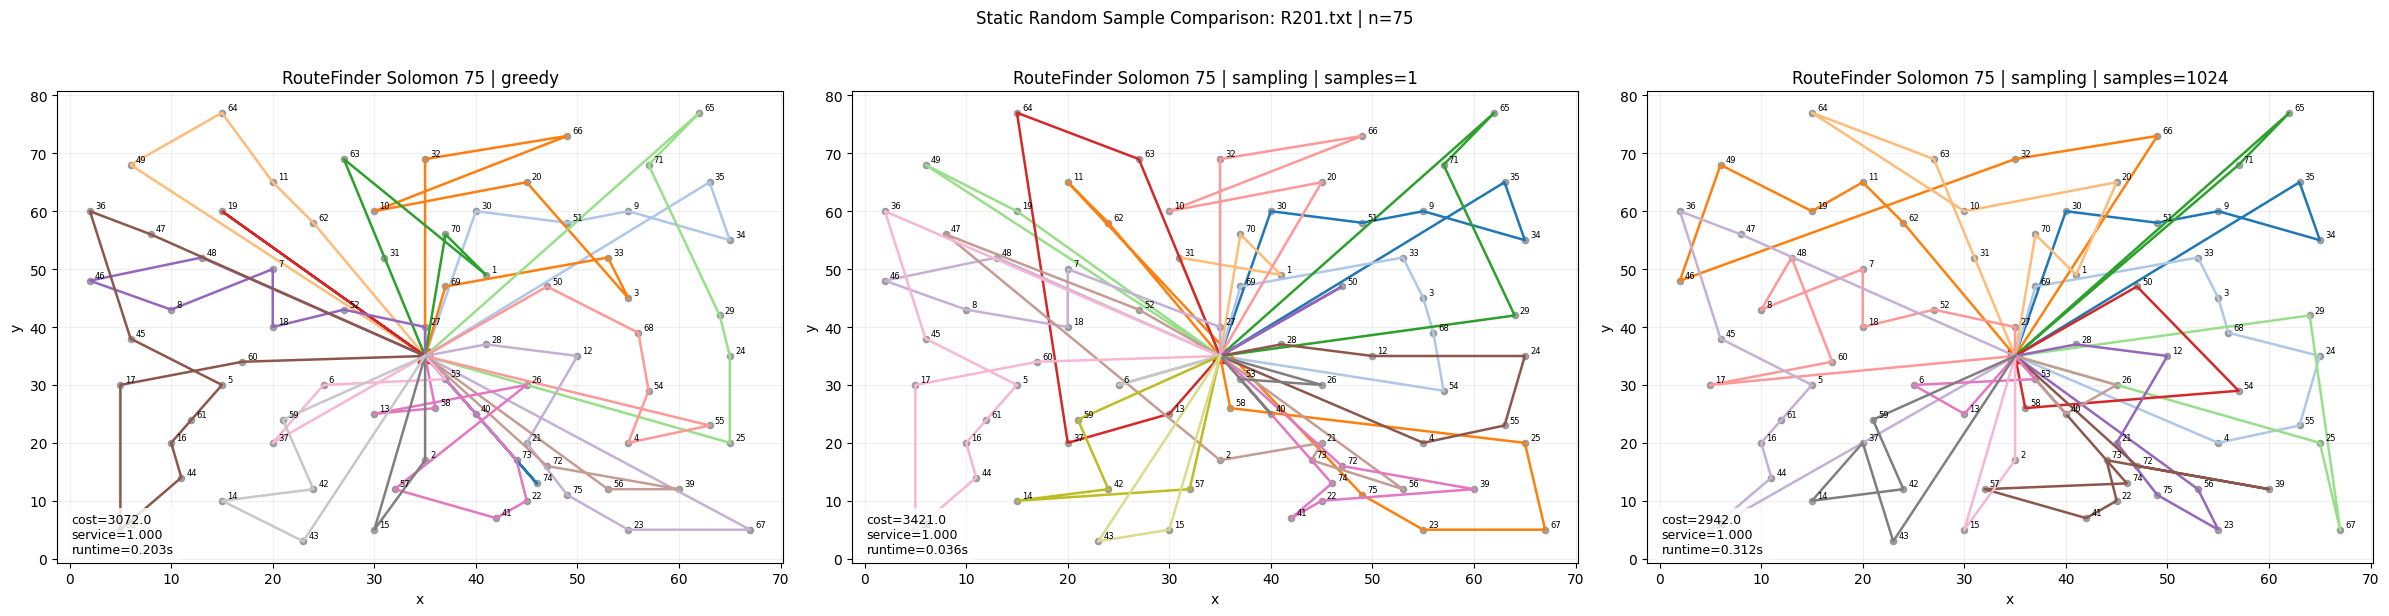

In [10]:
static_df = df[df["modality_group"].eq("static")].copy()

if static_df.empty:
    print("No static results found.")
else:
    compare_df = static_df[static_df["decode_type"].isin(["greedy", "sampling"])].copy()
    if compare_df.empty:
        print("No greedy/sampling static runs found.")
    else:
        summary = (
            compare_df.groupby(
                ["model_display_name", "evaluation_size", "decode_type", "num_samples", "num_augment", "select_best"],
                dropna=False,
                as_index=False,
            )
            .agg(
                runs=("model_name", "count"),
                total_cost_mean=("total_cost", "mean"),
                total_distance_mean=("total_distance", "mean"),
                service_level_mean=("service_level", "mean"),
                average_lateness_mean=("average_lateness", "mean"),
                runtime_mean=("computational_time", "mean"),
            )
            .sort_values(["model_display_name", "evaluation_size", "decode_type", "num_samples"], kind="stable")
        )
        display(summary)

        greedy_sampling = (
            compare_df.groupby(["model_display_name", "decode_type"], as_index=False)[["total_cost", "service_level", "computational_time"]]
            .mean()
            .sort_values(["model_display_name", "decode_type"], kind="stable")
        )
        display(greedy_sampling)

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        for metric, ax, title in [
            ("total_cost", axes[0], "Static Total Cost"),
            ("service_level", axes[1], "Static Service Level"),
            ("computational_time", axes[2], "Static Runtime"),
        ]:
            pivot = greedy_sampling.pivot(index="model_display_name", columns="decode_type", values=metric).sort_index()
            pivot.plot(kind="bar", ax=ax)
            ax.set_title(f"{title}: Greedy vs Sampling")
            ax.set_xlabel("")
            ax.grid(axis="y", alpha=0.2)
            ax.tick_params(axis="x", rotation=45)
        fig.tight_layout()

        pair_keys = (
            compare_df.groupby(["instance_id", "evaluation_size", "model_name"], as_index=False)["decode_type"]
            .nunique()
            .query("decode_type >= 2")[["instance_id", "evaluation_size", "model_name"]]
        )

        if pair_keys.empty:
            print("No matched greedy/sampling static pair available for side-by-side route plots.")
        else:
            pair = pair_keys.sample(1, random_state=None).iloc[0]
            pair_rows = compare_df[
                (compare_df["instance_id"].eq(pair["instance_id"]))
                & (compare_df["evaluation_size"].eq(pair["evaluation_size"]))
                & (compare_df["model_name"].eq(pair["model_name"]))
                & (compare_df["decode_type"].isin(["greedy", "sampling"]))
            ].sort_values(["decode_type", "num_samples"], kind="stable")

            dataset_root = SEARCH_ROOT.parent / "dataset"
            instance_path = dataset_root / pair["instance_id"]
            if not instance_path.exists():
                matches = list(dataset_root.rglob(pair["instance_id"]))
                if not matches:
                    raise FileNotFoundError(f"Could not locate {pair['instance_id']} under {dataset_root}")
                instance_path = matches[0]

            instance = parse_solomon(instance_path, max_customers=int(pair["evaluation_size"]))
            nodes = {n.id: n for n in instance.all_nodes}
            colors = plt.cm.tab20.colors

            fig, axes = plt.subplots(1, len(pair_rows), figsize=(8 * len(pair_rows), 6), squeeze=False)
            for ax, (_, row) in zip(axes[0], pair_rows.iterrows()):
                ax.scatter([instance.depot.x], [instance.depot.y], c="red", marker="s", s=90, label="Depot")
                ax.scatter([c.x for c in instance.customers], [c.y for c in instance.customers], c="gray", s=20, alpha=0.7)
                for i, route in enumerate(row["routes"]):
                    path = [instance.depot.id, *route["node_ids"], instance.depot.id]
                    xs = [nodes[n].x for n in path if n in nodes]
                    ys = [nodes[n].y for n in path if n in nodes]
                    ax.plot(xs, ys, color=colors[i % len(colors)], linewidth=1.8)
                    for nid in route["node_ids"]:
                        if nid in nodes:
                            ax.text(nodes[nid].x + 0.5, nodes[nid].y + 0.5, str(nid), fontsize=6)
                subtitle = f"{row['model_display_name']} | {row['decode_type']}"
                if row["decode_type"] == "sampling":
                    subtitle += f" | samples={int(row['num_samples'])}"
                ax.set_title(subtitle)
                ax.set_xlabel("x")
                ax.set_ylabel("y")
                ax.grid(alpha=0.2)
                ax.text(
                    0.02,
                    0.02,
                    f"cost={row['total_cost']:.1f}\nservice={row['service_level']:.3f}\nruntime={row['computational_time']:.3f}s",
                    transform=ax.transAxes,
                    fontsize=9,
                    bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "none"},
                )
            fig.suptitle(f"Static Random Sample Comparison: {pair['instance_id']} | n={int(pair['evaluation_size'])}", y=1.02)
            fig.tight_layout()
